# 🖱️ Advertising CTR Prediction
## Deep Cross Network (DCN) vs MLP on Avazu Dataset

**Task:** Binary classification — predict if a user will click an ad  
**Dataset:** [Avazu CTR Prediction](https://www.kaggle.com/c/avazu-ctr-prediction/data)  
**Architectures:** Multi-Layer Perceptron (MLP) + Deep & Cross Network (DCN v1)  
**Metrics:** AUC-ROC, Log Loss


In [1]:
# Install required packages
!pip install -q kaggle torch scikit-learn pandas numpy matplotlib seaborn tqdm
print("✅ Packages ready")


✅ Packages ready


## Kaggle  Data Download



In [4]:
# Data Download
import kagglehub

# Download latest version
path = kagglehub.competition_download('avazu-ctr-prediction')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/avazu-ctr-prediction


In [6]:
# Data Extraction
import gzip, shutil, os

train_gz_path = '/kaggle/input/competitions/avazu-ctr-prediction/train.gz'

print(f"Extracting {train_gz_path} ...")
with gzip.open(train_gz_path, 'rb') as f_in:
    with open('/kaggle/working/train', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("✅ Extracted → /kaggle/working/train")
!wc -l /kaggle/working/train

Extracting /kaggle/input/competitions/avazu-ctr-prediction/train.gz ...
✅ Extracted → /kaggle/working/train
40428968 /kaggle/working/train


## Imports & Configuration

In [7]:
# Config
import pandas as pd, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
from tqdm.notebook import tqdm
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"🖥️  Device  : {device}")
print(f"🔢 GPUs    : {num_gpus}x {torch.cuda.get_device_name(0)}")
print(f"💾 VRAM    : {num_gpus * 16} GB total")

TRAIN_FILE   = '/kaggle/working/train'
SAMPLE_SIZE  = 10_000_000   # 10M rows
BATCH_SIZE   = 8192
EPOCHS       = 5
LR           = 1e-3
EMBED_DIM_CAP = 50
DROPOUT      = 0.3
NUM_CROSS    = 3
DEEP_HIDDEN  = [512, 256, 128]
USE_AMP      = True # FP16 mixed precision on T4

🖥️  Device  : cuda
🔢 GPUs    : 2x Tesla T4
💾 VRAM    : 32 GB total


## Data Loading & Exploratory Analysis

In [8]:
# Load Data
print(f"Loading {SAMPLE_SIZE:,} rows ...")
df = pd.read_csv(TRAIN_FILE, nrows=SAMPLE_SIZE)
print(f"Shape : {df.shape}  |  CTR: {df['click'].mean()*100:.2f}%")
df.head(3)


Loading 10,000,000 rows ...
Shape : (10000000, 24)  |  CTR: 16.61%


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79


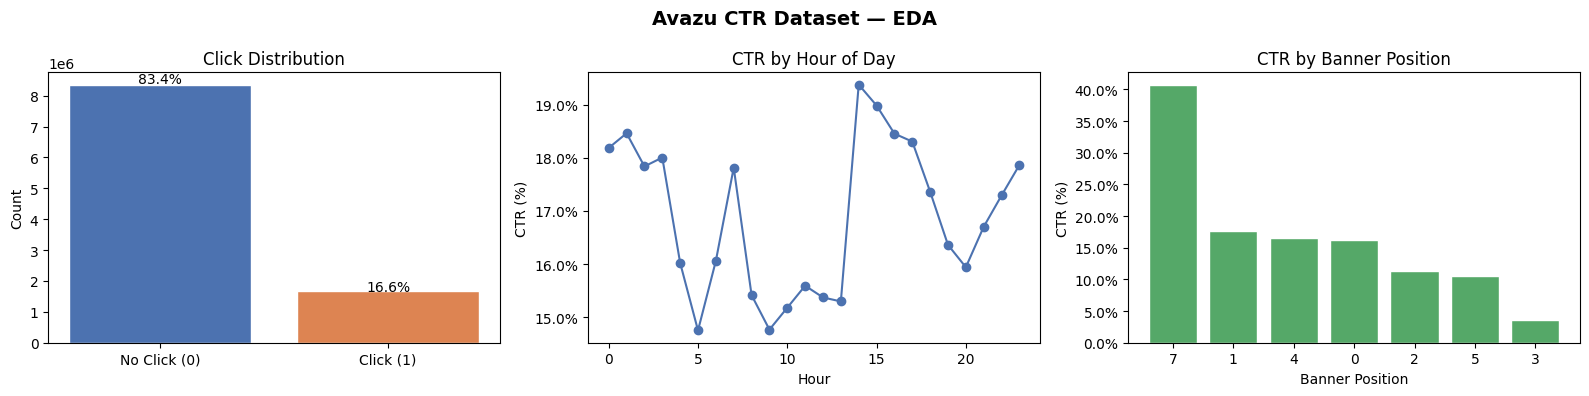

✅ EDA plots saved


In [9]:
# Exploratory Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Avazu CTR Dataset — EDA", fontsize=14, fontweight='bold')

# Class imbalance
counts = df['click'].value_counts()
axes[0].bar(['No Click (0)', 'Click (1)'], counts.values,
            color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[0].set_title('Click Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.01, f'{v/len(df)*100:.1f}%', ha='center', fontsize=10)

# CTR by hour of day
df['_hod'] = df['hour'].astype(str).str[-2:].astype(int)
ctr_by_hour = df.groupby('_hod')['click'].mean()
axes[1].plot(ctr_by_hour.index, ctr_by_hour.values * 100, marker='o', color='#4c72b0')
axes[1].set_title('CTR by Hour of Day')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('CTR (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# CTR by banner position
ctr_by_pos = df.groupby('banner_pos')['click'].mean().sort_values(ascending=False)
axes[2].bar(ctr_by_pos.index.astype(str), ctr_by_pos.values * 100,
            color='#55a868', edgecolor='white')
axes[2].set_title('CTR by Banner Position')
axes[2].set_xlabel('Banner Position'); axes[2].set_ylabel('CTR (%)')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved")


## Feature Engineering & Preprocessing

In [10]:
# Feature Engineering
# Extract time-based features from packed 'hour' column (format: YYMMDDHH)
df['hour_of_day'] = df['hour'].astype(str).str[-2:].astype(int)
df['day_of_week']  = df['hour'].apply(
    lambda x: pd.Timestamp('20' + str(x)[:6]).day_of_week
)

# Drop raw columns not used as features
df.drop(columns=['id', 'hour', '_hod'], inplace=True, errors='ignore')

TARGET   = 'click'
FEATURES = [c for c in df.columns if c != TARGET]

print(f"Target  : {TARGET}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Target  : click
Features (23): ['C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'hour_of_day', 'day_of_week']


In [11]:
# Label Encoding (all features are categorical in Avazu)
le_dict = {}
for col in FEATURES:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"  {col:20s}: {df[col].nunique():>6,} unique values")

print("\n✅ Label encoding complete")

  C1                  :      7 unique values
  banner_pos          :      7 unique values
  site_id             :  3,496 unique values
  site_domain         :  4,585 unique values
  site_category       :     23 unique values
  app_id              :  5,469 unique values
  app_domain          :    390 unique values
  app_category        :     33 unique values
  device_id           : 786,741 unique values
  device_ip           : 2,129,662 unique values
  device_model        :  6,863 unique values
  device_type         :      4 unique values
  device_conn_type    :      4 unique values
  C14                 :  1,030 unique values
  C15                 :      8 unique values
  C16                 :      9 unique values
  C17                 :    226 unique values
  C18                 :      4 unique values
  C19                 :     47 unique values
  C20                 :    168 unique values
  C21                 :     42 unique values
  hour_of_day         :     24 unique values
  day_

In [12]:
# Train / Val / Test Split
X = df[FEATURES].values.astype(np.int64)
y = df[TARGET].values.astype(np.float32)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
)

print(f"Train : {X_train.shape[0]:>10,} rows  (CTR {y_train.mean()*100:.2f}%)")
print(f"Val   : {X_val.shape[0]:>10,} rows  (CTR {y_val.mean()*100:.2f}%)")
print(f"Test  : {X_test.shape[0]:>10,} rows  (CTR {y_test.mean()*100:.2f}%)")


Train :  8,000,000 rows  (CTR 16.61%)
Val   :  1,000,000 rows  (CTR 16.61%)
Test  :  1,000,000 rows  (CTR 16.61%)


## PyTorch Dataset & Embedding Configuration

In [16]:
# PyTorch Dataset
class CTRDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CTRDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(CTRDataset(X_val, y_val),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(CTRDataset(X_test, y_test),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
print(f"✅ DataLoaders ready  (batch size = {BATCH_SIZE:,})")


✅ DataLoaders ready  (batch size = 8,192)


In [17]:
# Embedding Dimensions (min(50, vocab//2 + 1))
vocab_sizes = [int(df[col].max()) + 1 for col in FEATURES]
embed_dims  = [min(EMBED_DIM_CAP, max(4, vs // 2 + 1)) for vs in vocab_sizes]
total_embed = sum(embed_dims)

print(f"{'Feature':<22} | {'Vocab':>8} | {'EmbDim':>6}")
print("-" * 44)
for f, vs, ed in zip(FEATURES, vocab_sizes, embed_dims):
    print(f"  {f:<20} | {vs:>8,} | {ed:>6}")
print("-" * 44)
print(f"  {'TOTAL INPUT DIM':<20} | {'':>8} | {total_embed:>6}")


Feature                |    Vocab | EmbDim
--------------------------------------------
  C1                   |        7 |      4
  banner_pos           |        7 |      4
  site_id              |    3,496 |     50
  site_domain          |    4,585 |     50
  site_category        |       23 |     12
  app_id               |    5,469 |     50
  app_domain           |      390 |     50
  app_category         |       33 |     17
  device_id            |  786,741 |     50
  device_ip            | 2,129,662 |     50
  device_model         |    6,863 |     50
  device_type          |        4 |      4
  device_conn_type     |        4 |      4
  C14                  |    1,030 |     50
  C15                  |        8 |      5
  C16                  |        9 |      5
  C17                  |      226 |     50
  C18                  |        4 |      4
  C19                  |       47 |     24
  C20                  |      168 |     50
  C21                  |       42 |     22
  hour_o

## Model Architectures

### Baseline: Multi-Layer Perceptron (MLP)
Categorical features → Embedding Lookup → Concatenate → FC Layers → Sigmoid

### Main Model: Deep & Cross Network (DCN v1, Wang et al. 2017)
- **Cross Network**: Explicitly models feature interactions of bounded degree  
  `x_{l+1} = x_0 · (w_l^T · x_l) + b_l + x_l`
- **Deep Network**: Standard MLP for learning arbitrary non-linear patterns  
- **Output**: Concatenate cross + deep → Linear(1) → Sigmoid


In [18]:
# MLP Model
class MLP(nn.Module):
    def __init__(self, vocab_sizes, embed_dims,
                 hidden_dims=DEEP_HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, ed) for vs, ed in zip(vocab_sizes, embed_dims)
        ])
        self._init_embeddings()

        layers, in_dim = [], sum(embed_dims)
        for hd in hidden_dims:
            layers += [nn.Linear(in_dim, hd), nn.BatchNorm1d(hd),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = hd
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def _init_embeddings(self):
        for emb in self.embeddings:
            nn.init.xavier_uniform_(emb.weight)

    def forward(self, x):
        out = torch.cat([emb(x[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        return self.mlp(out).squeeze(1)


# Deep & Cross Network
class CrossLayer(nn.Module):
    """One cross interaction layer: x_{l+1} = x0 * (w^T x_l) + b + x_l"""
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(input_dim, 1))
        self.bias   = nn.Parameter(torch.zeros(input_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x0, x):
        # (batch, dim) × (dim, 1) → (batch, 1) × (1, dim) → (batch, dim)
        interaction = (x @ self.weight) * x0
        return interaction + self.bias + x


class DCN(nn.Module):
    def __init__(self, vocab_sizes, embed_dims,
                 num_cross=NUM_CROSS, deep_hidden=DEEP_HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, ed) for vs, ed in zip(vocab_sizes, embed_dims)
        ])
        self._init_embeddings()

        input_dim = sum(embed_dims)

        # Cross network
        self.cross_layers = nn.ModuleList(
            [CrossLayer(input_dim) for _ in range(num_cross)]
        )

        # Deep network
        deep_layers, d_in = [], input_dim
        for hd in deep_hidden:
            deep_layers += [nn.Linear(d_in, hd), nn.BatchNorm1d(hd),
                            nn.ReLU(), nn.Dropout(dropout)]
            d_in = hd
        self.deep = nn.Sequential(*deep_layers)

        # Combination layer
        self.output_layer = nn.Linear(input_dim + d_in, 1)

    def _init_embeddings(self):
        for emb in self.embeddings:
            nn.init.xavier_uniform_(emb.weight)

    def forward(self, x):
        x_embed = torch.cat([emb(x[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)

        # Cross part
        x0 = x_embed
        x_cross = x_embed
        for layer in self.cross_layers:
            x_cross = layer(x0, x_cross)

        # Deep part
        x_deep = self.deep(x_embed)

        # Combine
        combined = torch.cat([x_cross, x_deep], dim=1)
        return self.output_layer(combined).squeeze(1)


# Parameter count
mlp_model = MLP(vocab_sizes, embed_dims)
dcn_model = DCN(vocab_sizes, embed_dims)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"MLP parameters : {count_params(mlp_model):>12,}")
print(f"DCN parameters : {count_params(dcn_model):>12,}")


MLP parameters :  147,420,023
DCN parameters :  147,424,377


## Training Loop

In [25]:
# Training Function — DataParallel + AMP (FP16)
def train_model(model, train_loader, val_loader, model_name="Model",
                epochs=EPOCHS, lr=LR):

    # Wrap with DataParallel across both T4s
    if num_gpus > 1:
        print(f"  ⚡ Using DataParallel on {num_gpus}x T4")
        model = nn.DataParallel(model, device_ids=list(range(num_gpus)))
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', patience=1, factor=0.5)
    criterion = nn.BCEWithLogitsLoss()

    # AMP scaler — FP16 only (T4 does NOT support bfloat16)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_logloss': []}

    print(f"\n{'='*60}\n  Training {model_name}  [AMP={'FP16' if USE_AMP else 'OFF'}]\n{'='*60}")

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        running_loss = 0.0
        for X_b, y_b in tqdm(train_loader, desc=f"Ep {epoch}/{epochs} [Train]", leave=False):
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
                logits = model(X_b)
                loss   = criterion(logits, y_b)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * len(y_b)

        train_loss = running_loss / len(train_loader.dataset)

        # Validate
        model.eval()
        val_loss, preds, labels = 0.0, [], []
        with torch.no_grad():
            for X_b, y_b in tqdm(val_loader, desc=f"Ep {epoch}/{epochs} [Val]", leave=False):
                X_b, y_b = X_b.to(device), y_b.to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
                    logits = model(X_b)
                val_loss += criterion(logits, y_b).item() * len(y_b)
                preds.extend(torch.sigmoid(logits.float()).cpu().numpy())
                labels.extend(y_b.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_auc   = roc_auc_score(labels, preds)
        val_ll    = log_loss(labels, preds)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_logloss'].append(val_ll)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Ep {epoch:02d} | TrainLoss={train_loss:.4f} | "
      f"ValLoss={val_loss:.4f} | AUC={val_auc:.4f} | LogLoss={val_ll:.4f} | LR={current_lr:.2e}")

    print(f"{'='*60}\n")

    # Unwrap DataParallel before returning
    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    return history, raw_model

In [26]:
# Train MLP
mlp_model = MLP(vocab_sizes, embed_dims)
mlp_history, mlp_model = train_model(mlp_model, train_loader, val_loader, "MLP")


  ⚡ Using DataParallel on 2x T4

  Training MLP  [AMP=FP16]


Ep 1/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

Ep 1/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 01 | TrainLoss=0.3873 | ValLoss=0.3724 | AUC=0.7856 | LogLoss=0.3724 | LR=1.00e-03


Ep 2/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

...

Ep 4/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 04 | TrainLoss=0.2547 | ValLoss=0.4820 | AUC=0.7528 | LogLoss=0.4821 | LR=1.25e-04


Ep 5/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

Ep 5/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 05 | TrainLoss=0.2340 | ValLoss=0.5768 | AUC=0.7402 | LogLoss=0.5769 | LR=6.25e-05



In [27]:
# Train DCN
dcn_model = DCN(vocab_sizes, embed_dims)
dcn_history, dcn_model = train_model(dcn_model, train_loader, val_loader, "DCN")


  ⚡ Using DataParallel on 2x T4

  Training DCN  [AMP=FP16]


Ep 1/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

Ep 1/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 01 | TrainLoss=0.3819 | ValLoss=0.3729 | AUC=0.7844 | LogLoss=0.3729 | LR=1.00e-03


Ep 2/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

...

Ep 4/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 04 | TrainLoss=0.2561 | ValLoss=0.4861 | AUC=0.7510 | LogLoss=0.4862 | LR=1.25e-04


Ep 5/5 [Train]:   0%|          | 0/977 [00:00<?, ?it/s]

Ep 5/5 [Val]:   0%|          | 0/123 [00:00<?, ?it/s]

  Ep 05 | TrainLoss=0.2360 | ValLoss=0.5950 | AUC=0.7373 | LogLoss=0.5951 | LR=6.25e-05



## Test Set Evaluation & Visualizations

In [28]:
# Evaluation Helper
def evaluate(model, loader, name="Model"):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(device))
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(y_b.numpy())
    preds, labels = np.array(preds), np.array(labels)
    auc = roc_auc_score(labels, preds)
    ll  = log_loss(labels, preds)
    print(f"  {name:<6} → AUC = {auc:.4f}  |  Log Loss = {ll:.4f}")
    return auc, ll, preds, labels

print("\n── Test Set Results ──────────────────────────────")
mlp_auc, mlp_ll, mlp_preds, y_true = evaluate(mlp_model, test_loader, "MLP")
dcn_auc, dcn_ll, dcn_preds, _      = evaluate(dcn_model, test_loader, "DCN")



── Test Set Results ──────────────────────────────
  MLP    → AUC = 0.7391  |  Log Loss = 0.5795
  DCN    → AUC = 0.7360  |  Log Loss = 0.5979


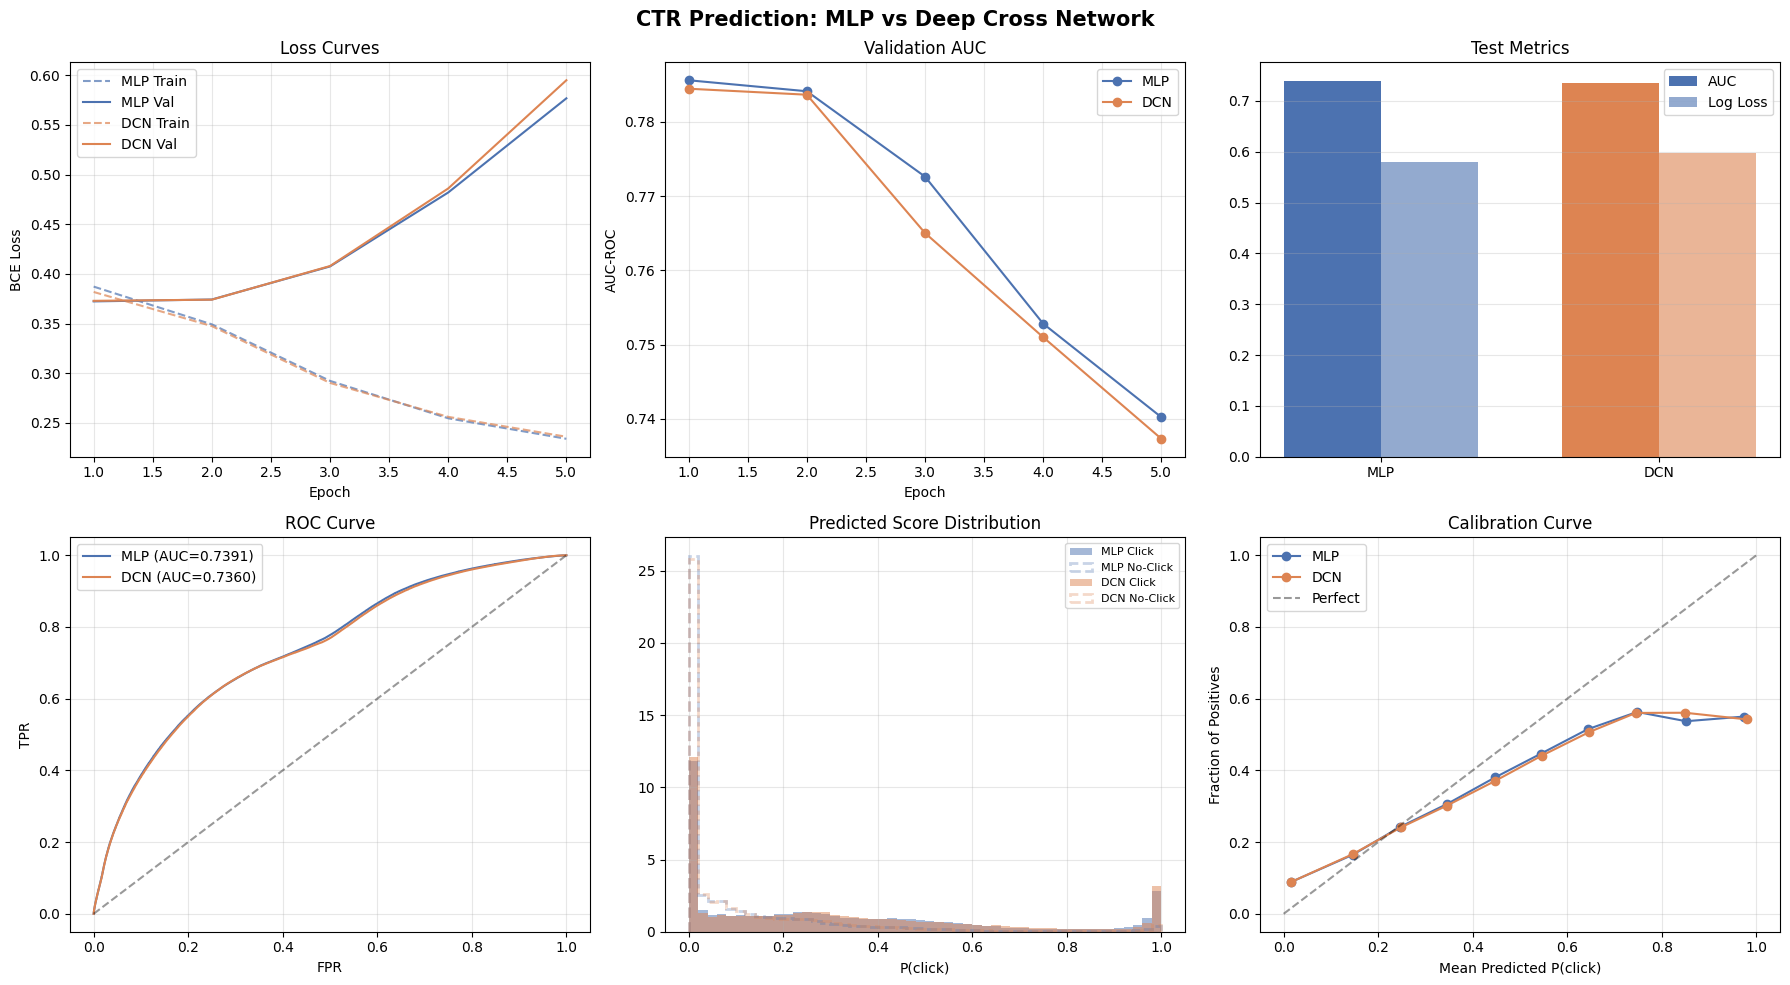

✅ Results plots saved


In [29]:
# Result Plots
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("CTR Prediction: MLP vs Deep Cross Network", fontsize=15, fontweight='bold')

colors = {'MLP': '#4c72b0', 'DCN': '#dd8452'}

# 18a. Training loss curves
for hist, name in [(mlp_history, 'MLP'), (dcn_history, 'DCN')]:
    axes[0][0].plot(range(1, EPOCHS+1), hist['train_loss'],
                    label=f'{name} Train', color=colors[name], linestyle='--', alpha=0.7)
    axes[0][0].plot(range(1, EPOCHS+1), hist['val_loss'],
                    label=f'{name} Val',   color=colors[name])
axes[0][0].set_title('Loss Curves'); axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('BCE Loss'); axes[0][0].legend(); axes[0][0].grid(alpha=0.3)

# 18b. Validation AUC
for hist, name in [(mlp_history, 'MLP'), (dcn_history, 'DCN')]:
    axes[0][1].plot(range(1, EPOCHS+1), hist['val_auc'],
                    label=name, color=colors[name], marker='o')
axes[0][1].set_title('Validation AUC'); axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('AUC-ROC'); axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

# 18c. Test metrics bar chart
metrics = {'AUC': [mlp_auc, dcn_auc], 'Log Loss': [mlp_ll, dcn_ll]}
x = np.arange(2); width = 0.35
for i, (metric, vals) in enumerate(metrics.items()):
    bars = axes[0][2].bar(x + i*width, vals, width, label=metric,
                          color=[colors['MLP'], colors['DCN']] if i == 0
                          else [colors['MLP']+'99', colors['DCN']+'99'])
axes[0][2].set_title('Test Metrics'); axes[0][2].set_xticks(x + width/2)
axes[0][2].set_xticklabels(['MLP', 'DCN']); axes[0][2].legend(); axes[0][2].grid(alpha=0.3, axis='y')

# 18d. ROC Curves
for preds, name in [(mlp_preds, 'MLP'), (dcn_preds, 'DCN')]:
    fpr, tpr, _ = roc_curve(y_true, preds)
    auc_val = roc_auc_score(y_true, preds)
    axes[1][0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=colors[name])
axes[1][0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1][0].set_title('ROC Curve'); axes[1][0].set_xlabel('FPR')
axes[1][0].set_ylabel('TPR'); axes[1][0].legend(); axes[1][0].grid(alpha=0.3)

# 18e. Prediction score distribution
for preds, name in [(mlp_preds, 'MLP'), (dcn_preds, 'DCN')]:
    axes[1][1].hist(preds[y_true==1], bins=50, alpha=0.5, label=f'{name} Click',
                    color=colors[name], density=True)
    axes[1][1].hist(preds[y_true==0], bins=50, alpha=0.3, label=f'{name} No-Click',
                    color=colors[name], density=True, linestyle='--', histtype='step', linewidth=2)
axes[1][1].set_title('Predicted Score Distribution')
axes[1][1].set_xlabel('P(click)'); axes[1][1].legend(fontsize=8); axes[1][1].grid(alpha=0.3)

# 18f. Calibration plot (reliability diagram)
from sklearn.calibration import calibration_curve
for preds, name in [(mlp_preds, 'MLP'), (dcn_preds, 'DCN')]:
    prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=10)
    axes[1][2].plot(prob_pred, prob_true, marker='o', label=name, color=colors[name])
axes[1][2].plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect')
axes[1][2].set_title('Calibration Curve'); axes[1][2].set_xlabel('Mean Predicted P(click)')
axes[1][2].set_ylabel('Fraction of Positives')
axes[1][2].legend(); axes[1][2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ctr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Results plots saved")


## Results Summary & Model Saving

In [30]:
# Final Summary Table
summary = pd.DataFrame({
    'Model'       : ['MLP',  'DCN'],
    'Parameters'  : [count_params(mlp_model), count_params(dcn_model)],
    'Test AUC'    : [mlp_auc, dcn_auc],
    'Test LogLoss': [mlp_ll,  dcn_ll],
    'Best Val AUC': [max(mlp_history['val_auc']), max(dcn_history['val_auc'])],
})
summary = summary.set_index('Model')
print("\n📊 Final Results")
print("="*55)
print(summary.to_string())
print("="*55)

winner = 'DCN' if dcn_auc > mlp_auc else 'MLP'
delta  = abs(dcn_auc - mlp_auc)
print(f"\n🏆 Winner: {winner}  (ΔAUC = +{delta:.4f})")



📊 Final Results
       Parameters  Test AUC  Test LogLoss  Best Val AUC
Model                                                  
MLP     147420023  0.739119      0.579486      0.785583
DCN     147424377  0.736036      0.597870      0.784444

🏆 Winner: MLP  (ΔAUC = +0.0031)


In [31]:
# Save Models
torch.save({
    'model_state_dict' : mlp_model.state_dict(),
    'vocab_sizes'      : vocab_sizes,
    'embed_dims'       : embed_dims,
    'features'         : FEATURES,
    'test_auc'         : mlp_auc,
}, 'mlp_ctr.pt')

torch.save({
    'model_state_dict' : dcn_model.state_dict(),
    'vocab_sizes'      : vocab_sizes,
    'embed_dims'       : embed_dims,
    'features'         : FEATURES,
    'test_auc'         : dcn_auc,
}, 'dcn_ctr.pt')

print("✅ Models saved: mlp_ctr.pt  |  dcn_ctr.pt")

# Download to local machine
from google.colab import files
files.download('mlp_ctr.pt')
files.download('dcn_ctr.pt')
files.download('ctr_results.png')


✅ Models saved: mlp_ctr.pt  |  dcn_ctr.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference — Single Sample Prediction

Example: load the saved DCN and predict click probability for a new ad impression.


In [32]:
# Single-Sample Inference Example
# Grab a random row from the test set
sample_idx = np.random.randint(0, len(X_test))
x_sample   = torch.LongTensor(X_test[sample_idx]).unsqueeze(0).to(device)
true_label  = int(y_test[sample_idx])

dcn_model.eval()
with torch.no_grad():
    prob = torch.sigmoid(dcn_model(x_sample)).item()

print(f"Sample index   : {sample_idx}")
print(f"True label     : {'Click ✅' if true_label == 1 else 'No Click ❌'}")
print(f"DCN prediction : {prob:.4f}  ({'Click' if prob > 0.5 else 'No Click'})")
print(f"\nFeature values:")
for feat, val in zip(FEATURES, X_test[sample_idx]):
    original_val = le_dict[feat].inverse_transform([val])[0]
    print(f"  {feat:<22}: {original_val}")

Sample index   : 121958
True label     : No Click ❌
DCN prediction : 0.0108  (No Click)

Feature values:
  C1                    : 1005
  banner_pos            : 0
  site_id               : 7294ea0f
  site_domain           : 863fa89d
  site_category         : 3e814130
  app_id                : ecad2386
  app_domain            : 7801e8d9
  app_category          : 07d7df22
  device_id             : a99f214a
  device_ip             : b7527496
  device_model          : f2790a6a
  device_type           : 1
  device_conn_type      : 0
  C14                   : 17239
  C15                   : 320
  C16                   : 50
  C17                   : 1973
  C18                   : 3
  C19                   : 39
  C20                   : -1
  C21                   : 23
  hour_of_day           : 8
  day_of_week           : 2
